C:\Users\CCSLab\AppData\Local\Temp\ipykernel_5804\143445405.py:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(4, 4))


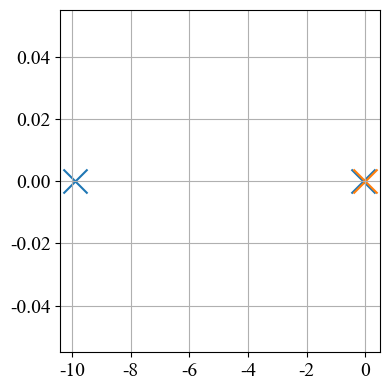

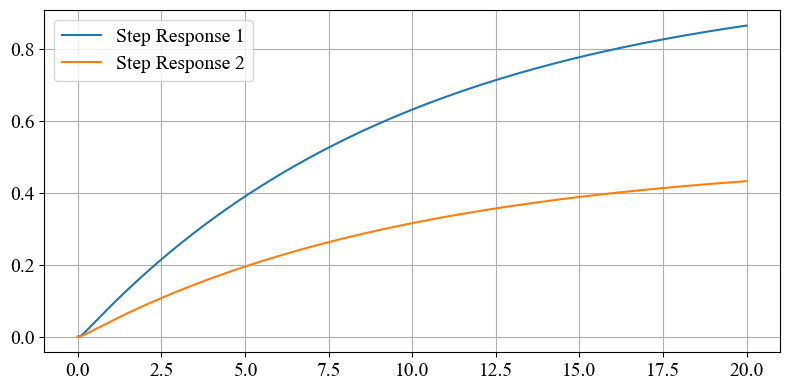

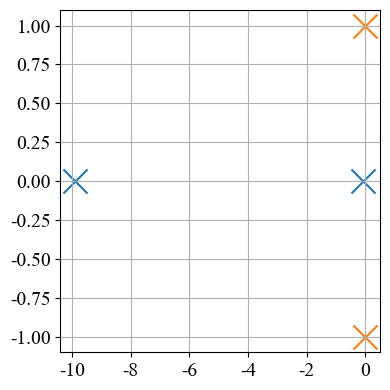

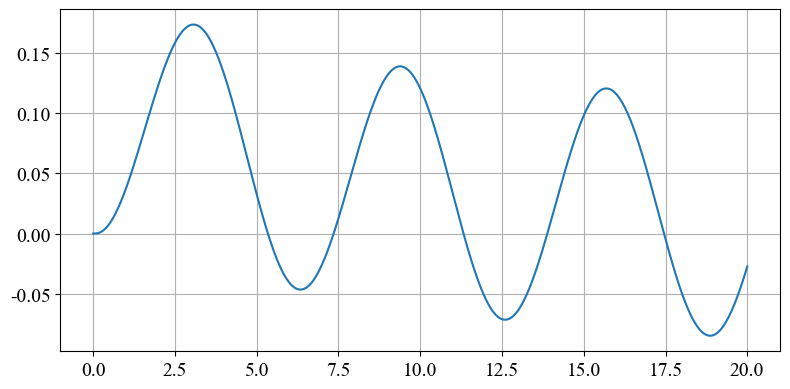

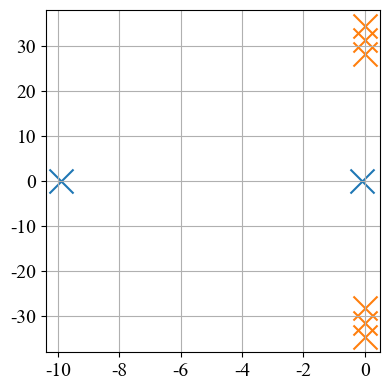

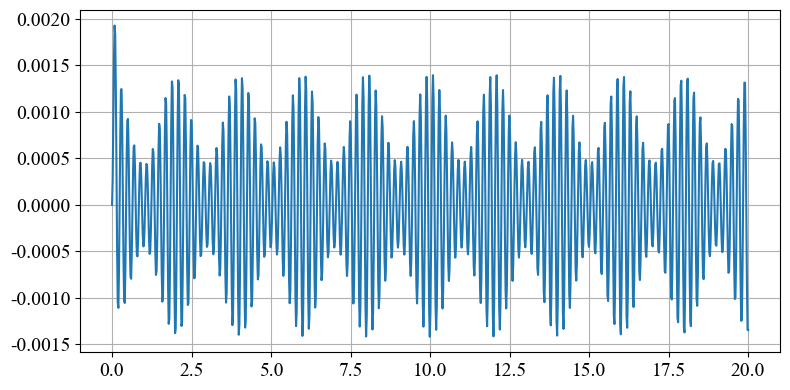

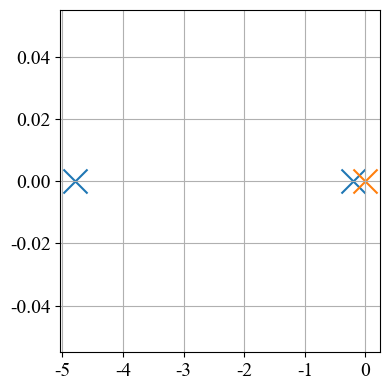

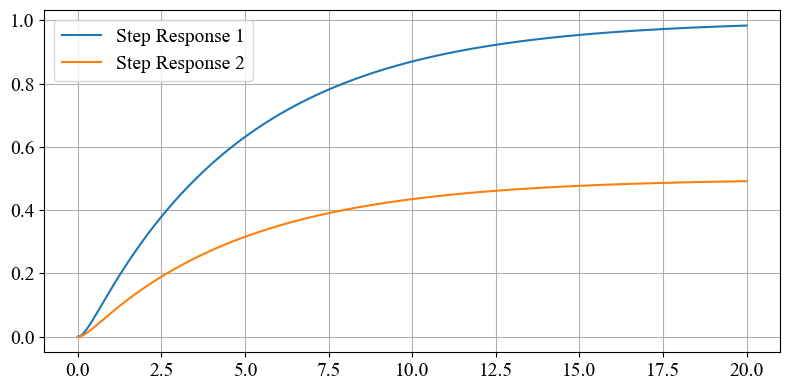

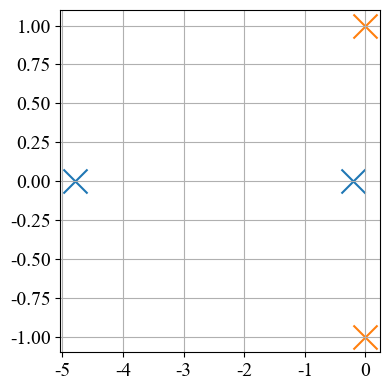

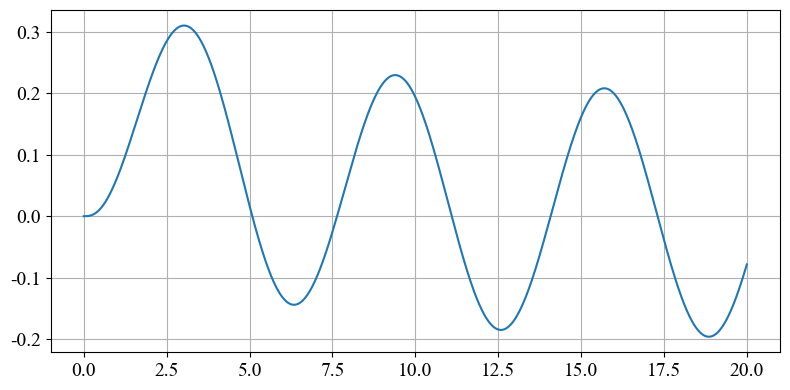

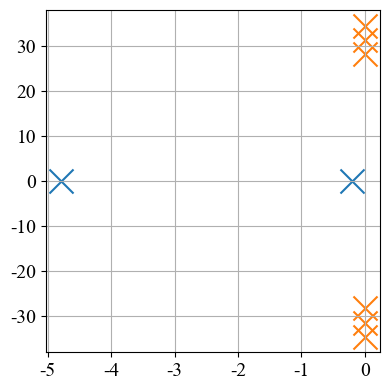

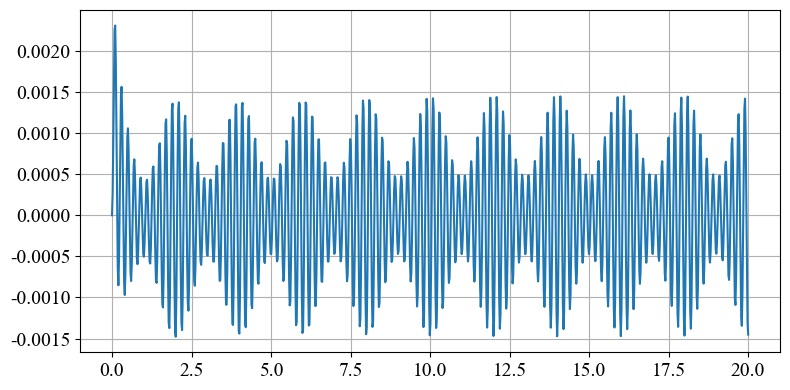

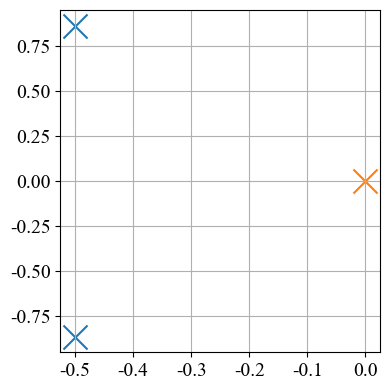

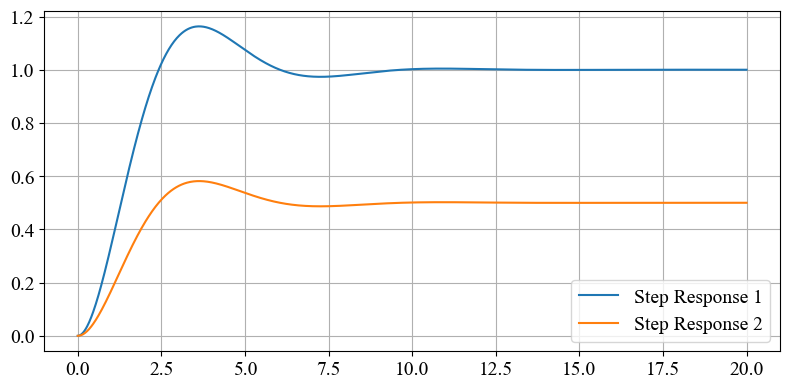

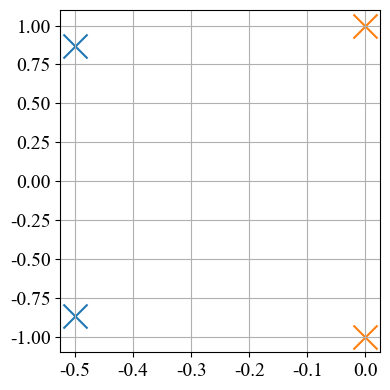

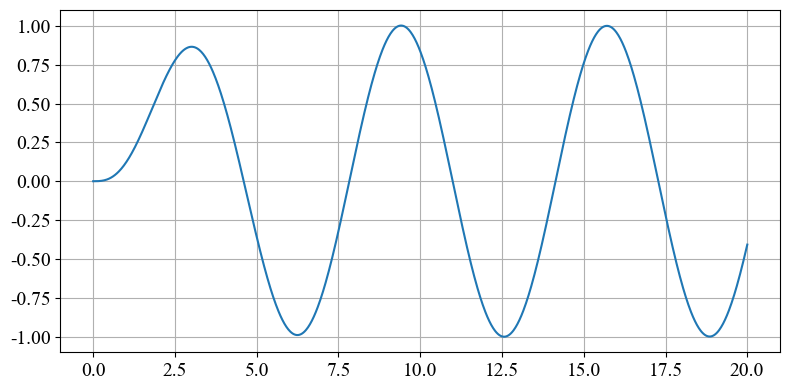

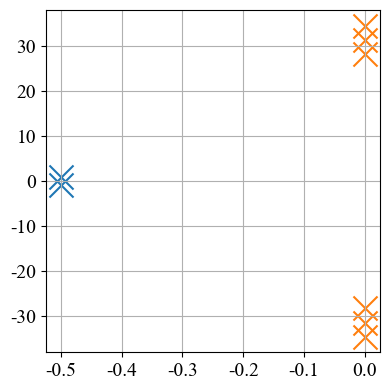

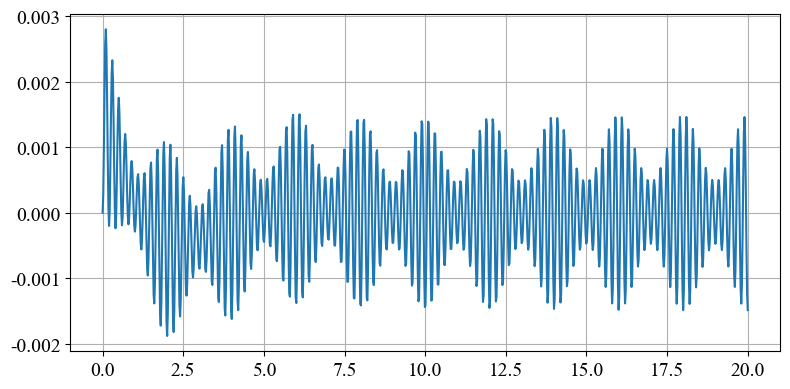

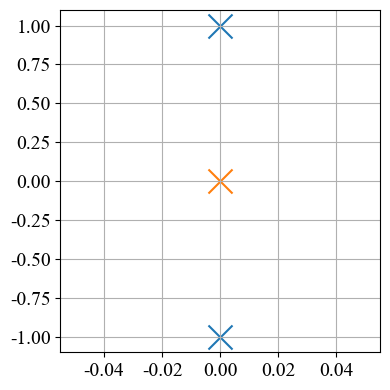

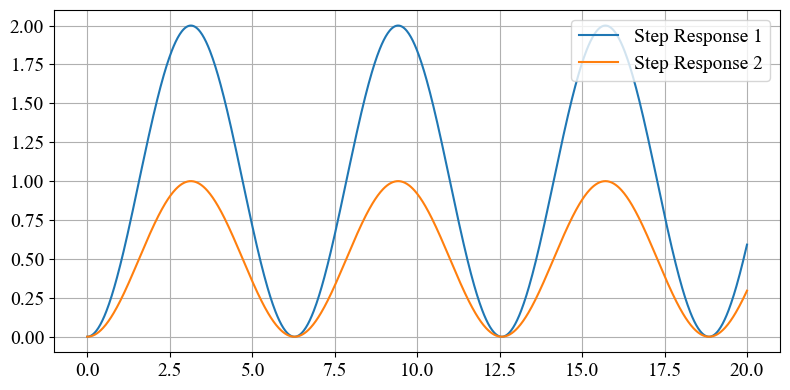

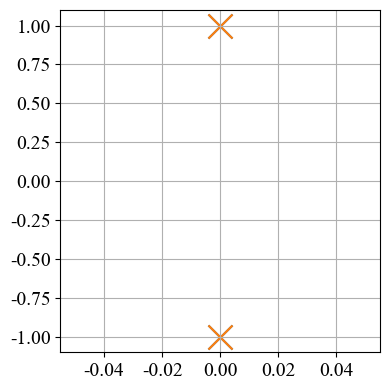

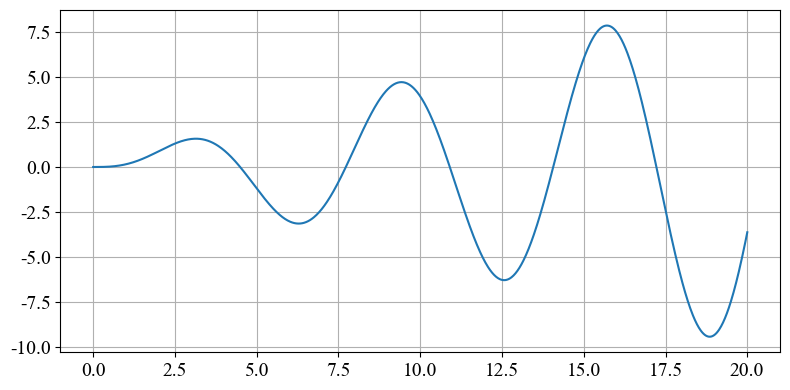

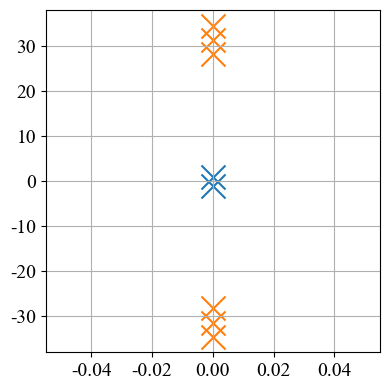

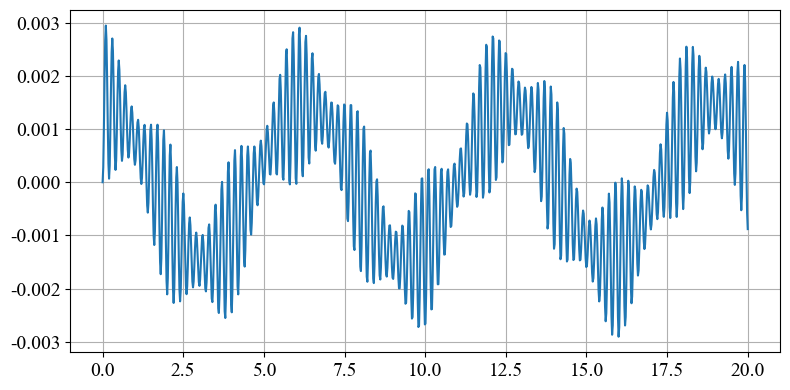

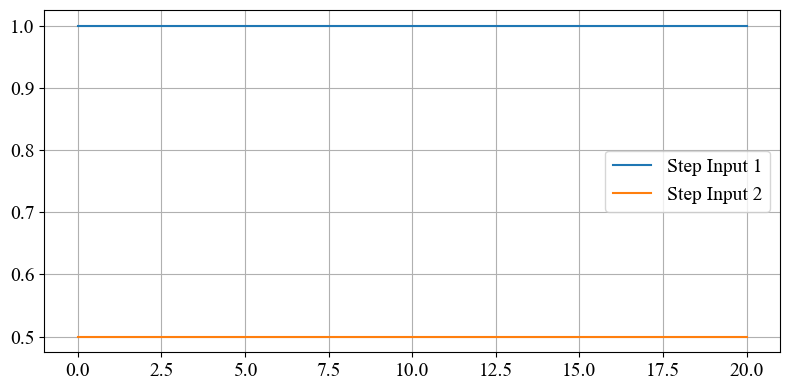

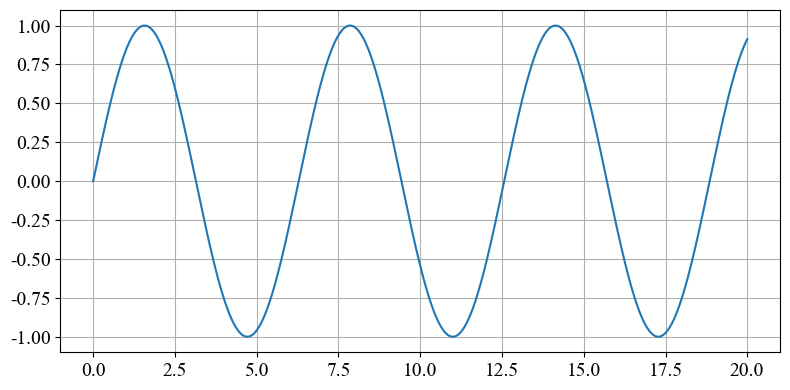

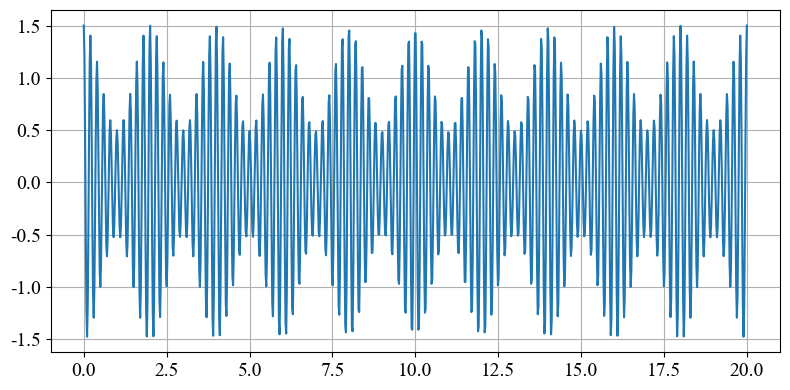

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lti, lsim
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False # 显示负号
plt.rcParams['mathtext.fontset']='stix'
# 定义系统参数
L = 1  # 电感值
C = 1  # 电容值

# 定义不同的电阻值
R_values = [10, 5, 1, 0]  # 电阻值列表

# 定义输入信号
input_name = ['Step Input', 'Sine Input', 'AM Input']
t = np.linspace(0, 20, 1000)
# impulse_input = 0.1* np.ones_like(t)  # 阶跃信号1
step_input = np.ones_like(t)  # 阶跃信号
sine_input = np.sin(t)  # 正弦信号
am_input = (1+0.5*np.cos(1*np.pi*t))*(np.cos(10*np.pi*t))  # 调幅信号
input_signal = [step_input, sine_input, am_input]
# 输入信号极点
step_poles = [[0], [0]]
sine_poles = [[0, 0], [1, -1]]
am_poles = [[0, 0, 0, 0, 0, 0], [9*np.pi, -9*np.pi, 10*np.pi, -10*np.pi,11*np.pi, -11*np.pi]]
input_poles = [step_poles, sine_poles, am_poles]

# 绘制系统极点&响应
for R in R_values:
    system = lti([1], [L*C, R*C, 1])
    poles = system.poles
    for i in range(3):
        # 系统极点
        plt.figure(figsize=(4, 4))
        plt.scatter(poles.real, poles.imag,label='System Poles', marker='x', s=300)
        # 输入信号极点
        plt.scatter(input_poles[i][0], input_poles[i][1],label=input_name[i], marker='x', s=300)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        # plt.xlabel('Real part of $s$', fontsize=18) 
        # plt.ylabel('Imaginary part of $s$', fontsize=18)
        # plt.title(input_name[i], fontsize=18)
        plt.tight_layout()
        # plt.legend(fontsize=14)
        plt.grid()
        
        plt.savefig('save/figure/lno/' + str(R) + '_' + input_name[i] + '_poles.svg')
        # 系统响应
        system = lti([1], [L*C, R*C, 1])
        t_input, y_input, _ = lsim(system, input_signal[i], t)
        plt.figure(figsize=(8, 4))
        plt.plot(t_input, y_input, label='Step Response 1')
        # 阶跃信号画2个图
        if i == 0:
            system = lti([1], [L*C, R*C, 1])
            t_input_2, y_input_2, _ = lsim(system, 0.5*input_signal[i], t)
            plt.plot(t_input_2, y_input_2, label='Step Response 2')
            plt.legend(fontsize=14)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        # plt.xlabel('$t$ / s', fontsize=18)
        # plt.ylabel('$U_C$ / V', fontsize=18)
        # plt.title(input_name[i], fontsize=18)
        plt.grid()
        plt.tight_layout()
        plt.savefig('save/figure/lno/' + str(R) + '_' + input_name[i] + '_response.svg')


# 绘制系统输入信号
for i in range(3):
    plt.figure(figsize=(8, 4))
    plt.plot(t, input_signal[i], label='Step Input 1')
    if i == 0:
        plt.plot(t, 0.5*input_signal[i], label='Step Input 2')
        plt.legend(fontsize=14)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.xlabel('$t$ / s', fontsize=18)
    # plt.ylabel('$U_i$ / V', fontsize=18)
    # plt.title('Input Signal', fontsize=18)
    plt.grid()
    plt.tight_layout()
    plt.savefig('save/figure/lno/' + input_name[i] + '_signal.svg')

# 绘制输入信号的极点
# plt.figure(figsize=(12, 8))
# plt.scatter([0], [0], label='Step Input Poles', marker='x', s=100)
# plt.scatter([0, 0], [1, -1], label='Sine Input Poles', marker='x', s=100)
# plt.ylim(-1.1, 1.1)
# plt.xlabel('Real part of $s$') 
# plt.ylabel('Imaginary part of $s$')
# plt.title('Input poles')
# plt.legend()
# plt.grid()
# plt.savefig('save/figure/lno/input_poles.svg')
# plt.show()

# 计算并绘制系统响应
# fig, axs = plt.subplots(3, 1, figsize=(15, 12))

# for R in R_values:
#     system = lti([1], [L*C, R*C, 1])
    
#     # # 冲激响应
#     # t_imp, y_imp, _ = lsim(system, impulse_input, t)
#     # axs[0].plot(t_imp, y_imp, label=f'R={R}')

#     # 调幅响应
#     t_am, y_am, _ = lsim(system, am_input, t)
#     axs[0].plot(t_am, y_am, label=f'R={R}')
    
#     # 阶跃响应
#     t_step, y_step, _ = lsim(system, step_input, t)
#     axs[1].plot(t_step, y_step, label=f'R={R}')
    
#     # 正弦响应
#     t_sine, y_sine, _ = lsim(system, sine_input, t)
#     axs[2].plot(t_sine, y_sine, label=f'R={R}')

# axs[0].set_title('Step Response 1')
# axs[1].set_title('Step Response 2')
# axs[2].set_title('Sine Response')

# for ax in axs:
#     ax.set(xlabel='$t$ / s', ylabel='$U_C$ / V')
#     ax.legend()
#     ax.grid()

# plt.tight_layout()
# plt.savefig('save/figure/lno/RLC_response.svg')
# plt.show()


# # 绘制系统输入信号
# plt.figure(figsize=(12, 8))
# plt.plot(t, am_input, label='AM Input')
# # plt.plot(t, impulse_input, label='Step Input 1')
# plt.plot(t, step_input, label='Step Input 2')
# plt.plot(t, sine_input, label='Sine Input')
# plt.xlabel('$t$ / s')
# plt.ylabel('$U_i$ / V')
# plt.title('Input Signal')
# plt.legend()
# plt.grid()
# plt.savefig('save/figure/lno/input_signal.svg')
# plt.show()

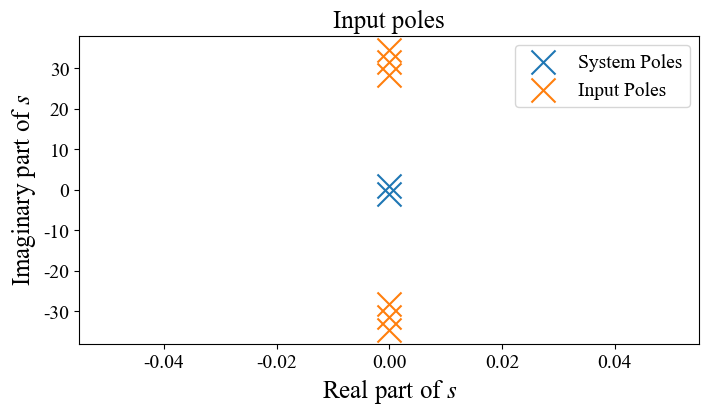

In [43]:
# 绘制极点
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lti, lsim
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False # 显示负号
plt.rcParams['mathtext.fontset']='stix'
plt.figure(figsize=(8, 4))
# plt.scatter([0], [0], label='Step Input Poles', marker='x', s=100)
# plt.scatter([0, 0], [1, -1], label='Sine Input Poles', marker='x', s=100)
plt.scatter([0, 0], [1, -1],label='System Poles', marker='x', s=300)
plt.scatter([0, 0, 0, 0, 0, 0], [9*np.pi, -9*np.pi, 10*np.pi, -10*np.pi,11*np.pi, -11*np.pi],label='Input Poles', marker='x', s=300)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.ylim(-1.1, 1.1)
plt.xlabel('Real part of $s$', fontsize=18) 
plt.ylabel('Imaginary part of $s$', fontsize=18)
plt.title('Input poles', fontsize=18)
plt.legend(fontsize=14)
# plt.grid()
plt.savefig('save/figure/lno/legend.svg')
plt.show()